# 04 - Experimentos y Comparaciones

Objetivo: comparar modelos con target log y visualizar resultados.

In [1]:
# Importar librerías y cargar datasets procesados
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

processed_dir = "../data/processed"
df_encoded = pd.read_csv(f"{processed_dir}/df_encoded.csv")
X_train = pd.read_csv(f"{processed_dir}/X_train.csv")
X_test = pd.read_csv(f"{processed_dir}/X_test.csv")
y_train = pd.read_csv(f"{processed_dir}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{processed_dir}/y_test.csv").squeeze()

In [2]:
# Modelos base A y B (sin log)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [3]:
# Modelos C y D (target log)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)
lr_log_pred_log = lr_log.predict(X_test_scaled)
lr_log_pred = np.expm1(lr_log_pred_log)

rf_log = RandomForestRegressor(n_estimators=100, random_state=42)
rf_log.fit(X_train, y_train_log)
rf_log_pred_log = rf_log.predict(X_test)
rf_log_pred = np.expm1(rf_log_pred_log)

In [4]:
# Comparar modelos A-D y guardar métricas
def calc_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

results = {
    "A_LR_no_log": calc_metrics(y_test, lr_pred),
    "B_RF_no_log": calc_metrics(y_test, rf_pred),
    "C_LR_log": calc_metrics(y_test, lr_log_pred),
    "D_RF_log": calc_metrics(y_test, rf_log_pred),
}

results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
print(results_df)
print("Mejor (mayor R2):", results_df.index[0])

metrics_dir = "../reports/metrics"
os.makedirs(metrics_dir, exist_ok=True)
results_df.to_csv(f"{metrics_dir}/model_comparison.csv", index=True)

                      MAE          RMSE        R2
C_LR_log     15526.261982  25788.448883  0.913297
B_RF_no_log  17814.268630  29408.882078  0.887243
D_RF_log     17718.628547  29430.283244  0.887079
A_LR_no_log  20607.582950  52614.109588  0.639097
Mejor (mayor R2): C_LR_log


,R2_pct,RMSE,MAE
C_LR_log,91.33,25788.45,15526.26
B_RF_no_log,88.72,29408.88,17814.27
D_RF_log,88.71,29430.28,17718.63
A_LR_no_log,63.91,52614.11,20607.58


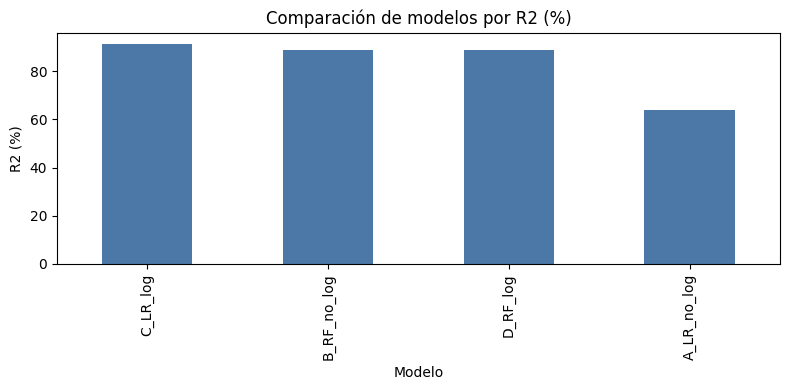

In [5]:
# Visualizar comparación por R2 y guardar gráfico
results_view = results_df[["R2", "RMSE", "MAE"]].copy()
results_view["R2_pct"] = results_view["R2"] * 100
display(results_view[["R2_pct", "RMSE", "MAE"]].round(2))

plt.figure(figsize=(8, 4))
results_view["R2_pct"].sort_values(ascending=False).plot(kind="bar", color="#4C78A8")
plt.title("Comparación de modelos por R2 (%)")
plt.ylabel("R2 (%)")
plt.xlabel("Modelo")
plt.tight_layout()

figures_dir = "../reports/figures"
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(f"{figures_dir}/model_comparison_r2.png", dpi=150)
plt.show()

## Conclusiones

- Linear Regression mejoró significativamente usando log transform.
- Random Forest mostró poca sensibilidad al log transform.
- El target original presenta skewness positiva importante.
- La transformación logarítmica estabilizó la distribución y mejoró generalización.